# FreshFlow - Data Quality Exploration

This notebook profiles the four raw CSV files that the Order Recommendations API ingests.
Goals:
- How many rows exist in each file
- How many rows are **clean** and ready to use as-is
- How many rows are **dirty** and need cleaning (and why)
- What patterns exist across files

**Important:** All CSVs are loaded with `dtype=str` so every cell is read exactly as it
appears in the file, so no silent type coercion. This makes every data quality issue visible.

---
## 0 · Setup

In [1]:
from pathlib import Path
import re
import warnings
from io import StringIO

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# paths ------------------------------------------------------------------------
DATA = Path("../data")

# Load everything as raw strings -> no automatic type conversion.
#   Why? If we let pandas infer types, it would silently fix
#   "1001.0" → 1001 and we'd never see the problem.
items = pd.read_csv(DATA / "items.csv", dtype=str)
inventory = pd.read_csv(DATA / "inventory.csv", dtype=str)

# orderable_items.csv has 240 rows with a trailing comma (phantom empty 10th field).
# A naive on_bad_lines="warn" read silently DROPS those rows instead of loading
# them (ADR.md: "parse the extra field, don't drop the row") -> strip the
# trailing comma first so every row parses.
_orderable_lines = (DATA / "orderable_items.csv").read_text().splitlines()
_orderable_header, *_orderable_rows = _orderable_lines
_orderable_rows = [r[:-1] if r.endswith(",") else r for r in _orderable_rows]
orderable = pd.read_csv(StringIO("\n".join([_orderable_header, *_orderable_rows])), dtype=str).fillna("")

recs = pd.read_csv(DATA / "order_recommendations.csv", dtype=str)

# style ---------------------------------------------------------------------------
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
HEALTHY_COLOR   = "#4CAF50"   # green
DIRTY_COLOR     = "#F44336"   # red
WARNING_COLOR   = "#FF9800"   # orange
NEUTRAL_COLOR   = "#90A4AE"   # grey

print("Data loaded.")
print(f"  items            : {len(items):,} rows")
print(f"  inventory        : {len(inventory):,} rows")
print(f"  orderable_items  : {len(orderable):,} rows")
print(f"  order_recs       : {len(recs):,} rows")

Data loaded.
  items            : 50 rows
  inventory        : 25,868 rows
  orderable_items  : 25,200 rows
  order_recs       : 25,627 rows


---
## 1 - Overview - Row and Column Counts

,Rows,Columns
File,,
items.csv,50,6
inventory.csv,"25,868",4
orderable_items.csv,"25,200",9
order_recommendations.csv,"25,627",5


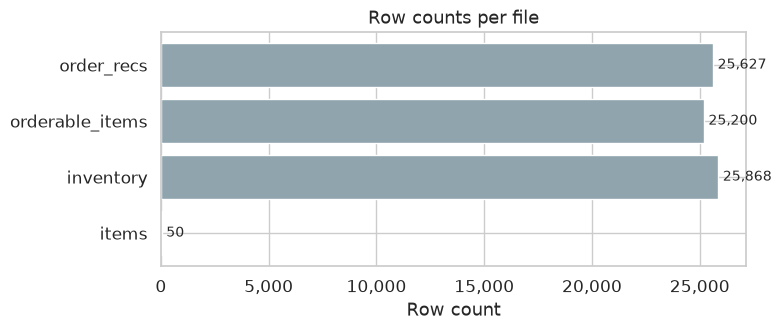

In [2]:
overview = pd.DataFrame([
    {"File": "items.csv",                "Rows": len(items),     "Columns": len(items.columns)},
    {"File": "inventory.csv",            "Rows": len(inventory), "Columns": len(inventory.columns)},
    {"File": "orderable_items.csv",      "Rows": len(orderable), "Columns": len(orderable.columns)},
    {"File": "order_recommendations.csv","Rows": len(recs),      "Columns": len(recs.columns)},
])
overview["Rows"] = overview["Rows"].apply(lambda x: f"{x:,}")
display(overview.set_index("File"))

# Bar chart of row counts
fig, ax = plt.subplots(figsize=(8, 3.5))
counts = [len(items), len(inventory), len(orderable), len(recs)]
labels = ["items", "inventory", "orderable_items", "order_recs"]
bars = ax.barh(labels, counts, color=[NEUTRAL_COLOR]*4)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f"{count:,}", va="center", fontsize=10)
ax.set_xlabel("Row count")
ax.set_title("Row counts per file")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

---
## 2 - items.csv

The global product catalog. **50 items**, no missing values, this is the cleanest file.
The problems are purely cosmetic: inconsistent capitalisation and trailing whitespace.

In [3]:
print("--- columns ---")
print(items.dtypes.to_string())
print("\n--- sample rows ---")
display(items.head(5))

--- columns ---
item_number               str
name                      str
category                  str
is_bio                    str
purchase_price            str
suggested_retail_price    str

--- sample rows ---


,item_number,name,category,is_bio,purchase_price,suggested_retail_price
0,1001,Organic Bananas,Fruits,False,0.89,1.49
1,1002,Red Apples Gala,Fruits,False,1.2,1.99
2,1003,Avocado Hass,Fruits,True,0.95,1.79
3,1004,Strawberries 500g,Fruits,False,1.5,2.99
4,1005,Blueberries 125g,Fruits,False,1.1,2.49


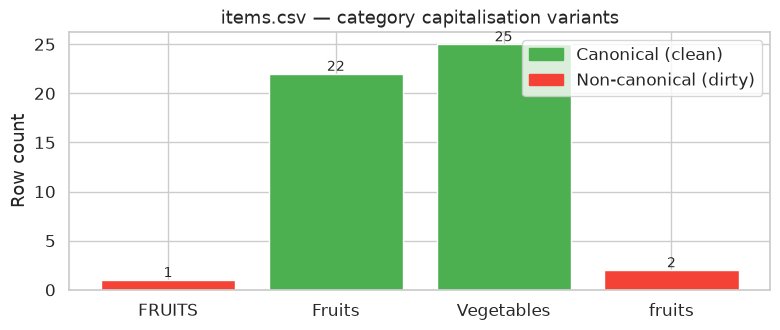


Dirty category rows (3):


,item_number,name,category
16,1017,Pomegranate,fruits
17,1018,Cherries 500g,FRUITS
24,1025,Figs Fresh 4-pack,fruits


In [4]:
# Category capitalisation -----------------------------------------------------------
cat_counts = items["category"].value_counts().sort_index()
canonical  = {"Fruits", "Vegetables"}  # the dominant forms
colors     = [HEALTHY_COLOR if v in canonical else DIRTY_COLOR for v in cat_counts.index]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(cat_counts.index, cat_counts.values, color=colors)
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha="center", fontsize=10)
ax.set_title("items.csv — category capitalisation variants")
ax.set_ylabel("Row count")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=HEALTHY_COLOR, label="Canonical (clean)"),
    Patch(color=DIRTY_COLOR,   label="Non-canonical (dirty)"),
])
plt.tight_layout()
plt.show()

dirty_cat = items[~items["category"].isin(canonical)]
print(f"\nDirty category rows ({len(dirty_cat)}):")
display(dirty_cat[["item_number","name","category"]])

In [5]:
# Trailing whitespace in name --------------------------------------------
trailing_ws = items[items["name"] != items["name"].str.strip()]
print(f"Rows with trailing whitespace in name: {len(trailing_ws)}")
if len(trailing_ws):
    display(trailing_ws[["item_number","name"]].assign(
        name_repr=trailing_ws["name"].apply(repr)
    )[["item_number","name_repr"]])

Rows with trailing whitespace in name: 4


,item_number,name_repr
27,1028,'Cucumber '
44,1045,'Eggplant '
45,1046,'Celery Stalk '
46,1047,'Pak Choi '


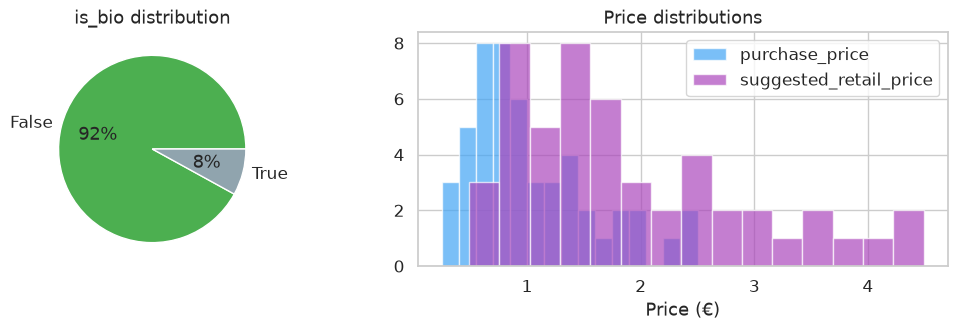

In [6]:
# is_bio distribution ----------------------------------------------
bio_counts = items["is_bio"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Pie
axes[0].pie(bio_counts.values, labels=bio_counts.index, autopct="%1.0f%%",
            colors=[HEALTHY_COLOR, NEUTRAL_COLOR])
axes[0].set_title("is_bio distribution")

# Price distributions
purchase = items["purchase_price"].astype(float)
retail   = items["suggested_retail_price"].astype(float)
axes[1].hist(purchase, bins=15, alpha=0.7, label="purchase_price",          color="#42A5F5")
axes[1].hist(retail,   bins=15, alpha=0.7, label="suggested_retail_price",  color="#AB47BC")
axes[1].set_title("Price distributions")
axes[1].set_xlabel("Price (€)")
axes[1].legend()

plt.tight_layout()
plt.show()

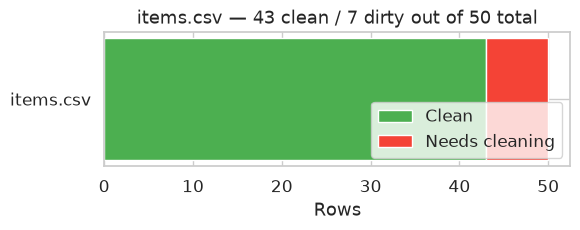

Category capitalisation issues : 3 rows
Trailing whitespace in name    : 4 rows
Missing values                 : 0 rows


In [7]:
# items.csv health summary ------------------------------------------------
items_dirty_cat  = len(items[~items["category"].isin({"Fruits", "Vegetables"})])
items_dirty_name = len(items[items["name"] != items["name"].str.strip()])
items_dirty      = len(set(items[~items["category"].isin({"Fruits","Vegetables"})].index) | set(items[items["name"] != items["name"].str.strip()].index))
items_clean      = len(items) - items_dirty

fig, ax = plt.subplots(figsize=(6, 2.5))
ax.barh(["items.csv"], [items_clean],   color=HEALTHY_COLOR, label="Clean")
ax.barh(["items.csv"], [items_dirty],   left=[items_clean],  color=DIRTY_COLOR,   label="Needs cleaning")
ax.set_xlabel("Rows")
ax.set_title(f"items.csv — {items_clean} clean / {items_dirty} dirty out of {len(items)} total")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Category capitalisation issues : {items_dirty_cat} rows")
print(f"Trailing whitespace in name    : {items_dirty_name} rows")
print("Missing values                 : 0 rows")

---
## 3 - inventory.csv

25,868 rows of daily stock levels across two stores.
Problems: 8 distinct `store_id` variants instead of 2, mixed date formats, one extremely large quantity outlier.

In [8]:
print("--- columns ---")
print(inventory.dtypes.to_string())
print("\n--- sample rows (raw strings) ---")
display(inventory.head(8))

--- columns ---
store_id       str
item_number    str
day            str
quantity       str

--- sample rows (raw strings) ---


,store_id,item_number,day,quantity
0,store_a,1001,2024-01-01,16.4
1,store_a,1001,2024-01-02,23.7
2,store_a,1001,2024-01-03,20.7
3,store_b,1014,2024-10-05,18.4
4,store_a,1001,2024-01-04,20.1
5,store_a,1001,2024-01-05,24.0
6,store_a,1001,2024-01-06,31.4
7,store_a,1001,2024-01-08,38.4


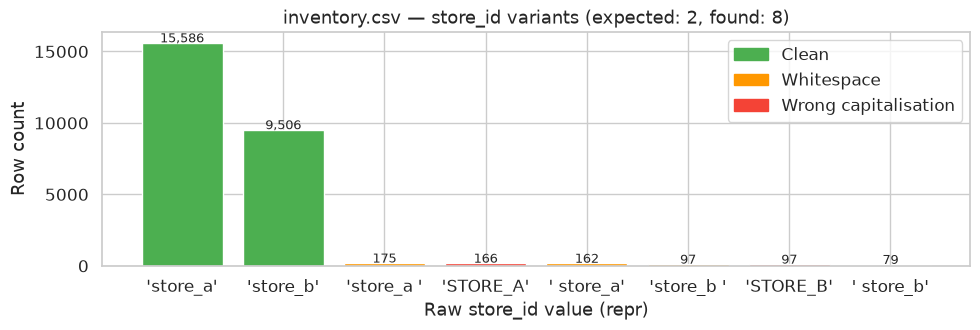

Rows with whitespace in store_id       : 513
Rows with all-caps store_id (STORE_A/B): 263


In [9]:
# store_id variants ----------------------------------------------------------
# We expect exactly 2 stores. How many raw variants exist?
sid_counts = inventory["store_id"].value_counts().sort_values(ascending=False)

# Classify each variant
def classify_store_id(sid):
    if sid != sid.strip():
        return "whitespace"
    if sid != sid.lower():
        return "caps"
    return "clean"

sid_df = pd.DataFrame({"store_id": sid_counts.index, "count": sid_counts.values})
sid_df["issue"] = sid_df["store_id"].apply(classify_store_id)
color_map = {"clean": HEALTHY_COLOR, "whitespace": WARNING_COLOR, "caps": DIRTY_COLOR}
bar_colors = [color_map[i] for i in sid_df["issue"]]

fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.bar(sid_df["store_id"].apply(repr), sid_df["count"], color=bar_colors)
for bar, val in zip(bars, sid_df["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,}", ha="center", fontsize=9)
ax.set_title("inventory.csv — store_id variants (expected: 2, found: 8)")
ax.set_ylabel("Row count")
ax.set_xlabel("Raw store_id value (repr)")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=HEALTHY_COLOR, label="Clean"),
    Patch(color=WARNING_COLOR, label="Whitespace"),
    Patch(color=DIRTY_COLOR,   label="Wrong capitalisation"),
])
plt.tight_layout()
plt.show()

n_whitespace = len(inventory[inventory["store_id"] != inventory["store_id"].str.strip()])
n_caps       = len(inventory[inventory["store_id"].str.upper() == inventory["store_id"]])
print(f"Rows with whitespace in store_id       : {n_whitespace:,}")
print(f"Rows with all-caps store_id (STORE_A/B): {n_caps:,}")

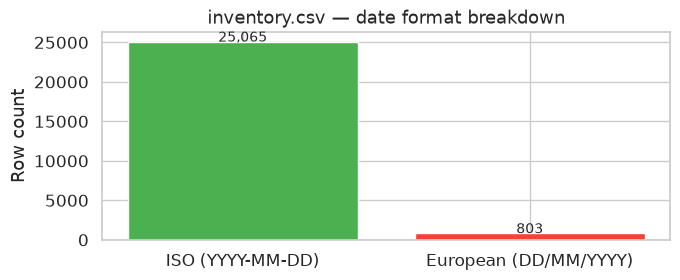


Sample European-format rows:


,store_id,item_number,day,quantity
20,store_a,1001,23/01/2024,24.0
105,store_a,1001,01/05/2024,22.7
110,store_a,1001,06/05/2024,39.7
123,store_a,1001,21/05/2024,25.8
160,store_a,1001,03/07/2024,21.5
195,store_a,1001,13/08/2024,21.3


In [10]:
# Date format analysis -------------------------------------
ISO_PATTERN    = re.compile(r"^\d{4}-\d{2}-\d{2}$")
EURO_PATTERN   = re.compile(r"^\d{2}/\d{2}/\d{4}$")

def date_format(d):
    d = str(d).strip()
    if ISO_PATTERN.match(d):  return "ISO (YYYY-MM-DD)"
    if EURO_PATTERN.match(d): return "European (DD/MM/YYYY)"
    return "Other / malformed"

inventory["_date_fmt"] = inventory["day"].apply(date_format)
fmt_counts = inventory["_date_fmt"].value_counts()

fig, ax = plt.subplots(figsize=(7, 3))
bar_c = [HEALTHY_COLOR if "ISO" in k else DIRTY_COLOR for k in fmt_counts.index]
bars = ax.bar(fmt_counts.index, fmt_counts.values, color=bar_c)
for bar, val in zip(bars, fmt_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}", ha="center", fontsize=10)
ax.set_title("inventory.csv — date format breakdown")
ax.set_ylabel("Row count")
plt.tight_layout()
plt.show()

print("\nSample European-format rows:")
display(inventory[inventory["_date_fmt"] == "European (DD/MM/YYYY)"][["store_id","item_number","day","quantity"]].head(6))
inventory.drop(columns=["_date_fmt"], inplace=True)

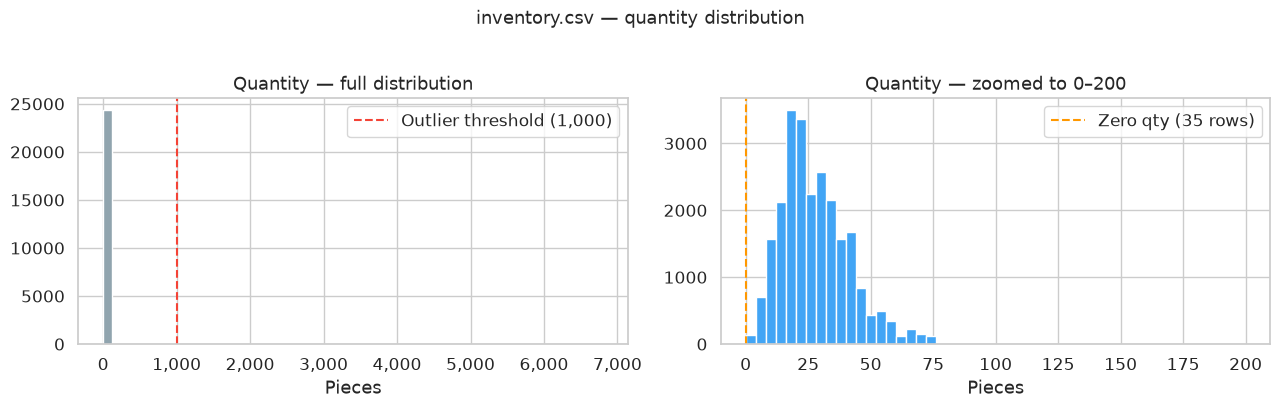

Min qty : 0.0
Max qty : 6,801.4  ← extreme outlier (item 1050, store_a)
Mean    : 172.08
Zeros   : 35
> 1,000 : 1,150

Top 10 largest quantities:


,store_id,item_number,day,quantity
15763,store_a,1050,2024-12-31,6801.4
15762,store_a,1050,30/12/2024,6785.7
15761,store_a,1050,2024-12-28,6769.5
15760,store_a,1050,2024-12-27,6744.3
15759,store_a,1050,2024-12-26,6717.5
15757,store_a,1050,2024-12-24,6714.3
15758,store_a,1050,2024-12-25,6690.0
15756,store_a,1050,2024-12-23,6685.2
15755,store_a,1050,2024-12-21,6665.3
15754,store_a,1050,2024-12-20,6644.6


In [11]:
# Quantity distribution ----------------------------------------
qty = inventory["quantity"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full distribution (note the extreme tail)
axes[0].hist(qty, bins=60, color=NEUTRAL_COLOR, edgecolor="white")
axes[0].axvline(1000, color=DIRTY_COLOR, linestyle="--", label="Outlier threshold (1,000)")
axes[0].set_title("Quantity — full distribution")
axes[0].set_xlabel("Pieces")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Zoomed: 0–200 (the typical range)
qty_zoom = qty[qty <= 200]
axes[1].hist(qty_zoom, bins=50, color="#42A5F5", edgecolor="white")
axes[1].axvline(0, color=WARNING_COLOR, linestyle="--", label=f"Zero qty ({(qty==0).sum()} rows)")
axes[1].set_title("Quantity — zoomed to 0–200")
axes[1].set_xlabel("Pieces")
axes[1].legend()

plt.suptitle("inventory.csv — quantity distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Min qty : {qty.min()}")
print(f"Max qty : {qty.max():,.1f}  ← extreme outlier (item 1050, store_a)")
print(f"Mean    : {qty.mean():.2f}")
print(f"Zeros   : {(qty == 0).sum()}")
print(f"> 1,000 : {(qty > 1000).sum():,}")

print("\nTop 10 largest quantities:")
display(inventory.assign(qty_num=qty).nlargest(10, "qty_num")[["store_id","item_number","day","quantity"]])

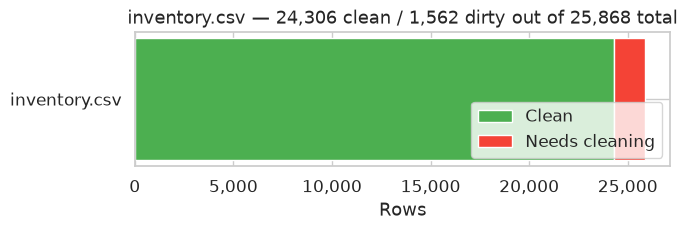

store_id whitespace or caps issues : 776 rows  (3.0%)
European date format               : 803 rows  (3.1%)


In [12]:
# inventory.csv health summary ------------------------------------------------------------
inv_dirty_sid  = (inventory["store_id"] != inventory["store_id"].str.strip()) | (inventory["store_id"].str.upper() == inventory["store_id"])
inv_dirty_date = inventory["day"].apply(date_format) != "ISO (YYYY-MM-DD)"
inv_dirty_mask = inv_dirty_sid | inv_dirty_date

n_clean = (~inv_dirty_mask).sum()
n_dirty = inv_dirty_mask.sum()

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.barh(["inventory.csv"], [n_clean], color=HEALTHY_COLOR, label="Clean")
ax.barh(["inventory.csv"], [n_dirty], left=[n_clean], color=DIRTY_COLOR, label="Needs cleaning")
ax.set_xlabel("Rows")
ax.set_title(f"inventory.csv — {n_clean:,} clean / {n_dirty:,} dirty out of {len(inventory):,} total")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"store_id whitespace or caps issues : {inv_dirty_sid.sum():,} rows  ({inv_dirty_sid.mean()*100:.1f}%)")
print(f"European date format               : {inv_dirty_date.sum():,} rows  ({inv_dirty_date.mean()*100:.1f}%)")

---
## 4 - orderable_items.csv

25,200 rows defining which items can be ordered per store per day.
Most complex file: missing value patterns, category casing, tag normalisation, trailing comma rows.

In [13]:
print("--- columns ---")
print(orderable.dtypes.to_string())
print("\n--- sample rows ---")
display(orderable.head(6))

--- columns ---
store_id                  str
item_number               str
ordering_day              str
delivery_day              str
purchase_price            str
suggested_retail_price    str
profit_margin             str
tags                      str
category                  str

--- sample rows ---


,store_id,item_number,ordering_day,delivery_day,purchase_price,suggested_retail_price,profit_margin,tags,category
0,store_a,1022,2024-09-30,2024-10-01,1.74,3.2,0.4474,,Fruits
1,store_b,1010,2024-05-16,2024-05-17,1.75,3.39,0.4777,new,Fruits
2,store_a,1032,2024-12-11,2024-12-12,0.52,1.0,0.5097,,Vegetables
3,store_a,1026,2024-01-03,2024-01-04,0.44,0.91,0.47,,Vegetables
4,store_b,1024,2024-12-02,2024-12-03,1.24,2.43,0.4891,,Fruits
5,store_a,1023,2024-06-26,2024-06-27,1.98,3.5,0.475,,Fruits


Empty cells per column:


,empty_count,empty_%
tags,23973,95.1
profit_margin,1299,5.2
purchase_price,1299,5.2


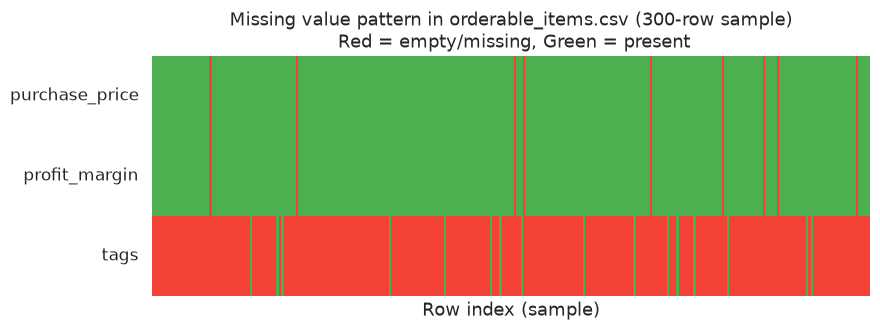


Missing both purchase_price AND profit_margin : 1,299
Missing only purchase_price                  : 0
Missing only profit_margin                   : 0
-> They are always co-missing, one can't be computed without the other.


In [14]:
# Missing values heatmap ----------------------------------------
# Check which columns have empty strings (our "null" since dtype=str).
empty_counts = (orderable == "").sum().sort_values(ascending=False)
empty_pct    = (empty_counts / len(orderable) * 100).round(1)

print("Empty cells per column:")
display(pd.DataFrame({"empty_count": empty_counts, "empty_%": empty_pct})
        [empty_counts > 0])

# Visualise the null pattern as a heatmap on a sample to keep it readable
# 1 = empty (missing), 0 = present
miss_cols = ["purchase_price", "profit_margin", "tags"]
miss_df = (orderable[miss_cols] == "").astype(int).sample(300, random_state=42)

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(miss_df.T, ax=ax, cmap=["#4CAF50", "#F44336"], cbar=False, yticklabels=miss_cols, xticklabels=False, linewidths=0)
ax.set_title("Missing value pattern in orderable_items.csv (300-row sample)\n Red = empty/missing, Green = present")
ax.set_xlabel("Row index (sample)")
plt.tight_layout()
plt.show()

# Prove the co-occurrence: purchase_price and profit_margin are ALWAYS missing together
both_missing = ((orderable["purchase_price"] == "") & (orderable["profit_margin"] == "")).sum()
only_pp      = ((orderable["purchase_price"] == "") & (orderable["profit_margin"] != "")).sum()
only_pm      = ((orderable["purchase_price"] != "") & (orderable["profit_margin"] == "")).sum()
print(f"\nMissing both purchase_price AND profit_margin : {both_missing:,}")
print(f"Missing only purchase_price                  : {only_pp}")
print(f"Missing only profit_margin                   : {only_pm}")
print("-> They are always co-missing, one can't be computed without the other.")

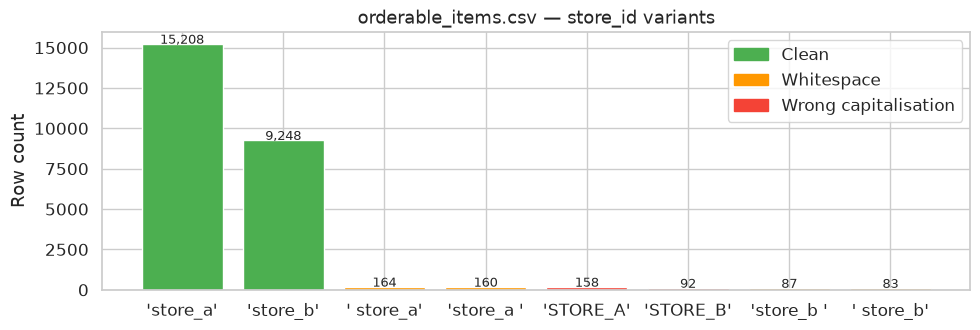

In [15]:
# store_id variants ----------------------------------
ord_sid_counts = orderable["store_id"].value_counts().sort_values(ascending=False)
ord_sid_df     = pd.DataFrame({"store_id": ord_sid_counts.index, "count": ord_sid_counts.values})
ord_sid_df["issue"] = ord_sid_df["store_id"].apply(classify_store_id)
bar_c = [color_map[i] for i in ord_sid_df["issue"]]

fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.bar(ord_sid_df["store_id"].apply(repr), ord_sid_df["count"], color=bar_c)
for bar, val in zip(bars, ord_sid_df["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}", ha="center", fontsize=9)
ax.set_title("orderable_items.csv — store_id variants")
ax.set_ylabel("Row count")
ax.legend(handles=[
    Patch(color=HEALTHY_COLOR, label="Clean"),
    Patch(color=WARNING_COLOR, label="Whitespace"),
    Patch(color=DIRTY_COLOR,   label="Wrong capitalisation"),
])
plt.tight_layout()
plt.show()

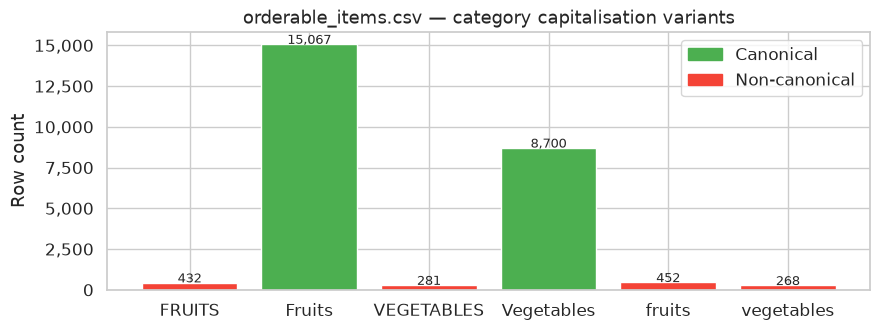

Non-canonical category rows: 1,433 (5.7%)


In [16]:
# Category capitalisation ---------------------------------
ord_cat = orderable["category"].value_counts().sort_index()
canonical_ord = {"Fruits", "Vegetables"}
ord_cat_colors = [HEALTHY_COLOR if v in canonical_ord else DIRTY_COLOR for v in ord_cat.index]

fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.bar(ord_cat.index, ord_cat.values, color=ord_cat_colors)
for bar, val in zip(bars, ord_cat.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{val:,}", ha="center", fontsize=9)
ax.set_title("orderable_items.csv — category capitalisation variants")
ax.set_ylabel("Row count")
ax.legend(handles=[
    Patch(color=HEALTHY_COLOR, label="Canonical"),
    Patch(color=DIRTY_COLOR,   label="Non-canonical"),
])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

n_dirty_cat = orderable[~orderable["category"].isin(canonical_ord)]
print(f"Non-canonical category rows: {len(n_dirty_cat):,} ({len(n_dirty_cat)/len(orderable)*100:.1f}%)")

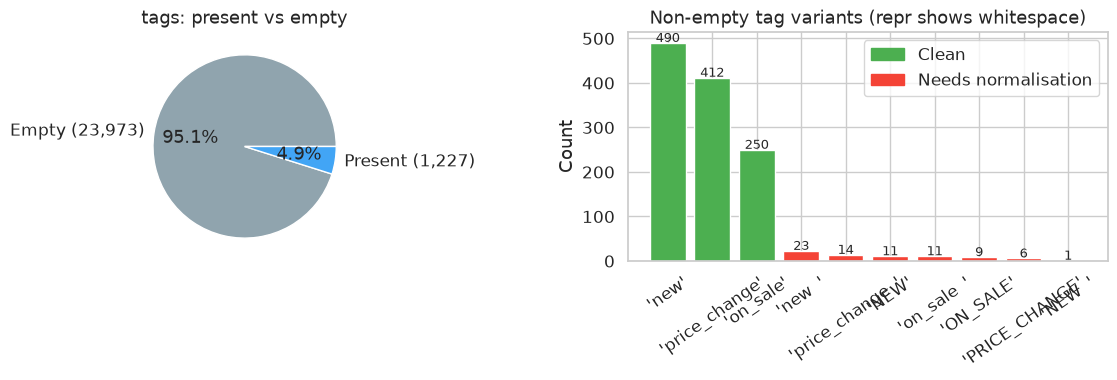

Tags needing normalisation: 75 rows


,tags,count
0,new,23
1,price_change,14
2,NEW,11
3,on_sale,11
4,ON_SALE,9
5,PRICE_CHANGE,6
6,NEW,1


In [17]:
# Tags breakdown ----------------------------------------
tags_present = (orderable["tags"] != "").sum()
tags_empty   = (orderable["tags"] == "").sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie: present vs empty
axes[0].pie([tags_empty, tags_present],
            labels=[f"Empty ({tags_empty:,})", f"Present ({tags_present:,})"],
            autopct="%1.1f%%",
            colors=[NEUTRAL_COLOR, "#42A5F5"])
axes[0].set_title("tags: present vs empty")

# Bar: value variants for non-empty tags
tag_vals = orderable[orderable["tags"] != ""]["tags"].value_counts()
canonical_tags = {"new", "price_change", "on_sale"}
tag_colors = [HEALTHY_COLOR if v.strip().lower() in canonical_tags and v == v.strip().lower() else DIRTY_COLOR for v in tag_vals.index]
bars = axes[1].bar(tag_vals.index.map(repr), tag_vals.values, color=tag_colors)
for bar, val in zip(bars, tag_vals.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), ha="center", fontsize=9)
axes[1].set_title("Non-empty tag variants (repr shows whitespace)")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend(handles=[
    Patch(color=HEALTHY_COLOR, label="Clean"),
    Patch(color=DIRTY_COLOR,   label="Needs normalisation"),
])

plt.tight_layout()
plt.show()

dirty_tags = tag_vals[~tag_vals.index.isin(canonical_tags)]
print(f"Tags needing normalisation: {dirty_tags.sum()} rows")
display(dirty_tags.rename("count").reset_index().rename(columns={"index":"raw_tag"}))

In [18]:
# Trailing comma rows ------------------------------------------------------
# orderable_items.csv has 240 raw rows with a trailing comma (10 fields instead
# of 9). The loader above strips it so these rows are included, not dropped --
# this just documents how many raw rows have the quirk.
raw_lines = (DATA / "orderable_items.csv").read_text().splitlines()
n_trailing = sum(1 for line in raw_lines[1:] if line.rstrip("\r\n").endswith(","))
print(f"Rows with trailing comma (10 fields instead of 9): {n_trailing:,}")
print("\nSample trailing-comma rows (raw):")
samples = [l for l in raw_lines[1:] if l.rstrip("\r\n").endswith(",")][:3]
for s in samples:
    print(" ", repr(s))

Rows with trailing comma (10 fields instead of 9): 240

Sample trailing-comma rows (raw):
  'store_a,1099,2024-01-13,2024-01-15,1.41,2.46,0.4514,,Fruits,'
  'store_a,1014,2024-10-03,2024-10-04,0.92,1.58,0.4146,,Fruits,'
  'store_a,1002,2024-08-15,2024-08-16,1.19,1.98,0.4055,,Fruits,'


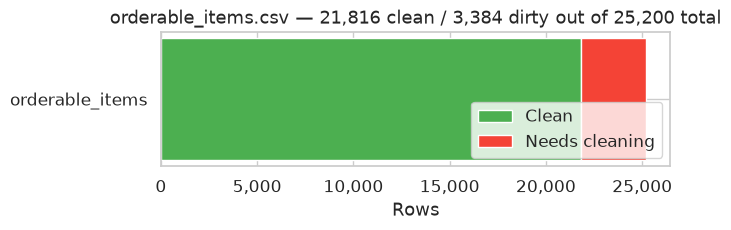

store_id issues          : 744 rows  (3.0%)
Category casing issues   : 1,433 rows  (5.7%)
Missing purchase_price   : 1,299 rows  (5.2%)
Tag normalisation needed : 75 rows  (0.3%)


In [19]:
# orderable_items.csv health summary --------------------------
ord_dirty_sid   = (orderable["store_id"] != orderable["store_id"].str.strip()) | (orderable["store_id"].str.upper() == orderable["store_id"])
ord_dirty_cat   = ~orderable["category"].isin(canonical_ord)
ord_dirty_miss  = orderable["purchase_price"] == ""
ord_dirty_tags  = (orderable["tags"] != "") & ((orderable["tags"] != orderable["tags"].str.strip()) | (orderable["tags"] != orderable["tags"].str.lower()))

ord_dirty_mask = ord_dirty_sid | ord_dirty_cat | ord_dirty_miss | ord_dirty_tags
n_ord_clean = (~ord_dirty_mask).sum()
n_ord_dirty = ord_dirty_mask.sum()

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.barh(["orderable_items"], [n_ord_clean], color=HEALTHY_COLOR, label="Clean")
ax.barh(["orderable_items"], [n_ord_dirty], left=[n_ord_clean], color=DIRTY_COLOR, label="Needs cleaning")
ax.set_xlabel("Rows")
ax.set_title(f"orderable_items.csv — {n_ord_clean:,} clean / {n_ord_dirty:,} dirty out of {len(orderable):,} total")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"store_id issues          : {ord_dirty_sid.sum():,} rows  ({ord_dirty_sid.mean()*100:.1f}%)")
print(f"Category casing issues   : {ord_dirty_cat.sum():,} rows  ({ord_dirty_cat.mean()*100:.1f}%)")
print(f"Missing purchase_price   : {ord_dirty_miss.sum():,} rows  ({ord_dirty_miss.mean()*100:.1f}%)")
print(f"Tag normalisation needed : {ord_dirty_tags.sum():,} rows  ({ord_dirty_tags.mean()*100:.1f}%)")

---
## 5 - order_recommendations.csv

25,627 rows of AI-generated order quantities.
Most interesting problems: float-encoded item numbers, negative recommended quantities (clearly erroneous), and extreme outliers.

In [20]:
print("--- columns ---")
print(recs.dtypes.to_string())
print("\n--- sample rows ---")
display(recs.head(6))

--- columns ---
store_id                str
item_number             str
ordering_day            str
delivery_day            str
recommended_quantity    str

--- sample rows ---


,store_id,item_number,ordering_day,delivery_day,recommended_quantity
0,store_a,1001,2024-01-01,2024-01-02,18
1,store_a,1001,2024-01-02,2024-01-03,10
2,store_a,1001,2024-01-03,2024-01-04,15
3,store_a,1001,2024-01-04,2024-01-05,15
4,store_a,1001,2024-01-05,2024-01-06,25
5,store_a,1001,2024-01-06,2024-01-08,22


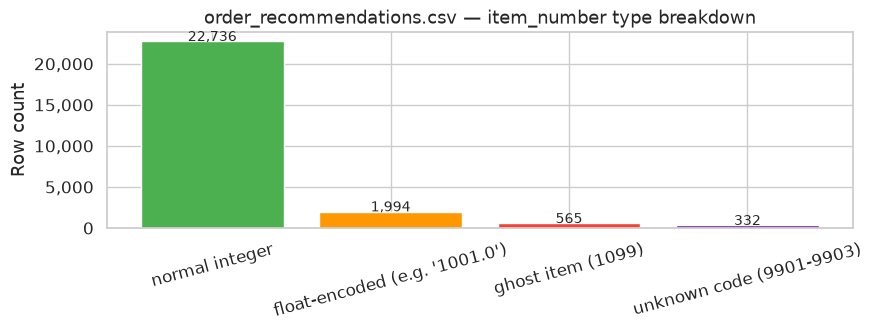


Sample float-encoded item numbers:


,item_number,store_id,ordering_day,recommended_quantity
54,1001.0,store_a,2024-03-05,17
94,1001.0,store_a,2024-04-22,0
98,1001.0,store_a,2024-04-26,19
107,1001.0,store_a,2024-05-07,5
108,1001.0,store_a,2024-05-08,19


In [21]:
# item_number type breakdown --------------------
# Known valid item numbers (from items.csv)
valid_items = set(items["item_number"].str.strip())

def classify_item_number(val):
    val = str(val).strip()
    # Float-encoded integer: has a decimal point followed only by zeros
    if re.match(r"^\d+\.0+$", val):
        return "float-encoded (e.g. '1001.0')"
    try:
        int_val = str(int(val))
    except ValueError:
        return "unparseable"
    if int_val in {"9901", "9902", "9903"}:
        return "unknown code (9901-9903)"
    if int_val == "1099":
        return "ghost item (1099)"
    return "normal integer"

recs["_item_cls"] = recs["item_number"].apply(classify_item_number)
item_cls_counts = recs["_item_cls"].value_counts()

item_colors = {
    "normal integer":            HEALTHY_COLOR,
    "float-encoded (e.g. '1001.0')": WARNING_COLOR,
    "ghost item (1099)":         DIRTY_COLOR,
    "unknown code (9901-9903)": "#7B1FA2",
}

fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.bar(item_cls_counts.index, item_cls_counts.values, color=[item_colors.get(k, NEUTRAL_COLOR) for k in item_cls_counts.index])
for bar, val in zip(bars, item_cls_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}", ha="center", fontsize=10)
ax.set_title("order_recommendations.csv — item_number type breakdown")
ax.set_ylabel("Row count")
ax.tick_params(axis="x", rotation=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print("\nSample float-encoded item numbers:")
display(recs[recs["_item_cls"] == "float-encoded (e.g. '1001.0')"][["item_number","store_id","ordering_day","recommended_quantity"]].head(5))
recs.drop(columns=["_item_cls"], inplace=True)

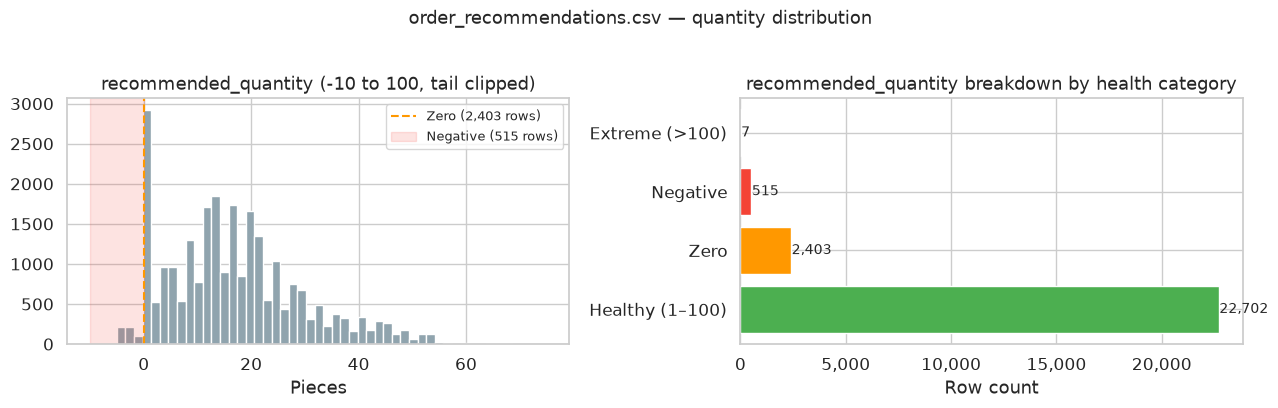

Min : -5  ← negative values are invalid
Max : 1939  ← extreme outlier (item 1009)
Mean: 17.14
Negative rows : 515  (2.0%)
Zero rows     : 2,403  (9.4%)
Outliers >100 : 7


In [22]:
# recommended_quantity distribution ----------------------------
rec_qty = recs["recommended_quantity"].astype(float)

n_negative = (rec_qty < 0).sum()
n_zero     = (rec_qty == 0).sum()
n_outlier  = (rec_qty > 100).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram — clip the long tail for readability
plot_qty = rec_qty[(rec_qty >= -10) & (rec_qty <= 100)]
axes[0].hist(plot_qty, bins=50, color=NEUTRAL_COLOR, edgecolor="white")
axes[0].axvline(0, color=WARNING_COLOR, linestyle="--", linewidth=1.5, label=f"Zero ({n_zero:,} rows)")
axes[0].axvspan(-10, 0, alpha=0.15, color=DIRTY_COLOR, label=f"Negative ({n_negative:,} rows)")
axes[0].set_title("recommended_quantity (-10 to 100, tail clipped)")
axes[0].set_xlabel("Pieces")
axes[0].legend(fontsize=9)

# Stacked bar: healthy, zero, negative, outlier
n_healthy  = len(rec_qty) - n_negative - n_zero - n_outlier
categories = ["Healthy (1–100)", "Zero", "Negative", "Extreme (>100)"]
values     = [n_healthy, n_zero, n_negative, n_outlier]
bar_colors = [HEALTHY_COLOR, WARNING_COLOR, DIRTY_COLOR, "#7B1FA2"]
bars = axes[1].barh(categories, values, color=bar_colors)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2, f"{val:,}", va="center", fontsize=10)
axes[1].set_title("recommended_quantity breakdown by health category")
axes[1].set_xlabel("Row count")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("order_recommendations.csv — quantity distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Min : {rec_qty.min():.0f}  ← negative values are invalid")
print(f"Max : {rec_qty.max():.0f}  ← extreme outlier (item 1009)")
print(f"Mean: {rec_qty.mean():.2f}")
print(f"Negative rows : {n_negative:,}  ({n_negative/len(rec_qty)*100:.1f}%)")
print(f"Zero rows     : {n_zero:,}  ({n_zero/len(rec_qty)*100:.1f}%)")
print(f"Outliers >100 : {n_outlier:,}")

In [23]:
# Negative quantities detail -----------------------
neg_rows = recs[rec_qty < 0].copy()
neg_rows["recommended_quantity"] = neg_rows["recommended_quantity"].astype(int)
print(f"Negative recommended_quantity rows: {len(neg_rows):,}")
print("\nValue distribution:")
display(neg_rows["recommended_quantity"].value_counts().sort_index())
print("\nSample rows:")
display(neg_rows[["store_id","item_number","ordering_day","recommended_quantity"]].head(8))

Negative recommended_quantity rows: 515

Value distribution:


recommended_quantity
-5    115
-4     92
-3    114
-2     99
-1     95
Name: count, dtype: int64


Sample rows:


,store_id,item_number,ordering_day,recommended_quantity
89,store_a,1001,2024-04-16,-5
152,store_a,1001,2024-06-28,-2
195,store_a,1001,2024-08-17,-2
217,store_a,1001,2024-09-12,-2
247,store_a,1001,2024-10-17,-4
277,store_a,1001,2024-11-22,-1
356,store_a,1002,2024-02-23,-4
368,store_a,1002,2024-03-08,-5


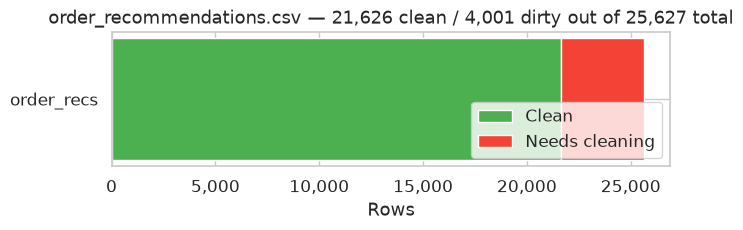

store_id issues           : 738 rows  (2.9%)
Float-encoded item_number : 2,891 rows  (11.3%)
Negative quantities       : 515 rows  (2.0%)


In [24]:
# order_recommendations.csv health summary ----------------------
rec_sid = recs["store_id"]
rec_dirty_sid = (rec_sid != rec_sid.str.strip()) | (rec_sid.str.upper() == rec_sid)
rec_dirty_qty = rec_qty < 0
rec_dirty_item = recs["item_number"].apply(classify_item_number) != "normal integer"

rec_dirty_mask = rec_dirty_sid | rec_dirty_qty | rec_dirty_item
n_rec_clean = (~rec_dirty_mask).sum()
n_rec_dirty = rec_dirty_mask.sum()

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.barh(["order_recs"], [n_rec_clean], color=HEALTHY_COLOR, label="Clean")
ax.barh(["order_recs"], [n_rec_dirty], left=[n_rec_clean], color=DIRTY_COLOR, label="Needs cleaning")
ax.set_xlabel("Rows")
ax.set_title(f"order_recommendations.csv — {n_rec_clean:,} clean / {n_rec_dirty:,} dirty out of {len(recs):,} total")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

print(f"store_id issues           : {rec_dirty_sid.sum():,} rows  ({rec_dirty_sid.mean()*100:.1f}%)")
print(f"Float-encoded item_number : {rec_dirty_item.sum():,} rows  ({rec_dirty_item.mean()*100:.1f}%)")
print(f"Negative quantities       : {rec_dirty_qty.sum():,} rows  ({rec_dirty_qty.mean()*100:.1f}%)")

---
## 6 - Cross-file Referential Integrity

Do records in one file have matching records in the others?
Key questions: what happens to **ghost items** and **special codes** when the API joins the tables?

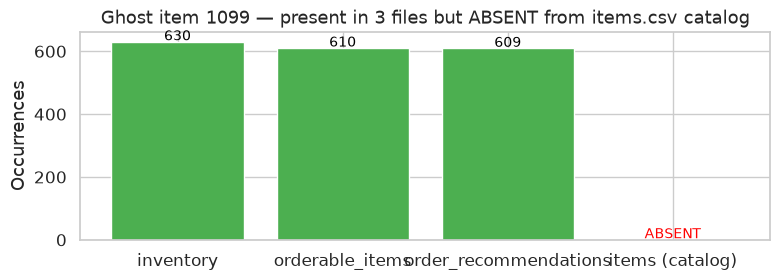

Impact: item 1099 is orderable but missing from items.csv. Per ADR.md, the
recommendation still gets served -> name falls back to the raw item_number
(not a fabricated 'Unknown'), and a catalog-gap warning gets logged.


In [25]:
# Ghost item 1099 -----------------------------------------------------
# item 1099 appears in three files but has NO entry in items.csv.
# Per ADR.md: items.csv is enrichment-only, never a gate -- a missing catalog
# entry does NOT drop the recommendation. Fallback name is the raw item_number
# (never a fabricated 'Unknown'), plus a logged catalog-gap warning.

def count_item(df, col="item_number", val="1099"):
    return (df[col].str.strip().str.replace(".0", "", regex=False) == val).sum()

ghost_counts = {
    "inventory": count_item(inventory),
    "orderable_items": count_item(orderable),
    "order_recommendations": count_item(recs),
    "items (catalog)": count_item(items),
}

fig, ax = plt.subplots(figsize=(8, 3))
bar_c = [HEALTHY_COLOR if v > 0 and k != "items (catalog)" else (DIRTY_COLOR if k == "items (catalog)" and v == 0 else NEUTRAL_COLOR) for k, v in ghost_counts.items()]
bars = ax.bar(ghost_counts.keys(), ghost_counts.values(), color=bar_c)
for bar, val in zip(bars, ghost_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:,}" if val > 0 else "ABSENT", ha="center", fontsize=10,
            color="red" if val == 0 else "black")
ax.set_title("Ghost item 1099 — present in 3 files but ABSENT from items.csv catalog")
ax.set_ylabel("Occurrences")
plt.tight_layout()
plt.show()

print("Impact: item 1099 is orderable but missing from items.csv. Per ADR.md, the")
print("recommendation still gets served -> name falls back to the raw item_number")
print("(not a fabricated 'Unknown'), and a catalog-gap warning gets logged.")

In [26]:
# Special codes 9901–9903 ---------------------------------------------
# These appear only in order_recommendations, not in any other file.
# They will be completely filtered out by the INNER JOIN on orderable_items.

special_codes = ["9901", "9902", "9903"]

def count_special(df, col="item_number"):
    cleaned = df[col].str.strip().str.replace(".0", "", regex=False)
    return {code: (cleaned == code).sum() for code in special_codes}

files_to_check = {
    "items": items,
    "inventory": inventory,
    "orderable_items": orderable,
    "order_recs": recs,
}

presence = pd.DataFrame({name: count_special(df) for name, df in files_to_check.items()})
print("Special code presence across files (0 = absent):")
display(presence.style.map(lambda v: "background-color: #F44336; color: white" if v > 0 else "background-color: #4CAF50; color: white"))

print("\nImpact: 9901–9903 exist only in order_recommendations.")
print("The INNER JOIN on orderable_items will filter them out, they never reach the API response.")

Special code presence across files (0 = absent):


,items,inventory,orderable_items,order_recs
9901,0,0,0,97
9902,0,0,0,118
9903,0,0,0,117



Impact: 9901–9903 exist only in order_recommendations.
The INNER JOIN on orderable_items will filter them out, they never reach the API response.


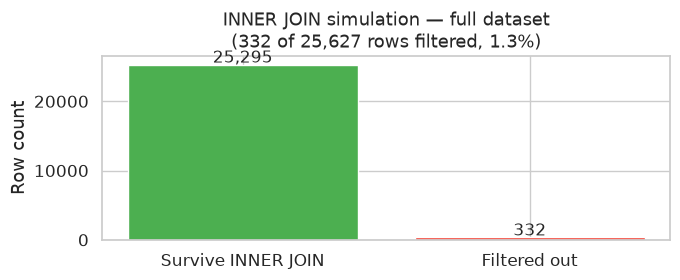

Across all 25,627 recommendations: 25,295 survive the INNER JOIN, 332 are filtered (1.3%).

Why rows get filtered:
_item
Special code (9901-9903)    332


In [27]:
# INNER JOIN simulation ------------------------------------------------
# Simulate what the API's INNER JOIN does, across the FULL dataset.
# (A single sample date would be misleading: not every date has a
# 9901-9903 row, so a one-date demo can show zero filtering by chance.)

def norm_sid(s): return str(s).strip().lower()
def norm_item(s): return str(int(float(str(s).strip())))

recs["_sid"]  = recs["store_id"].apply(norm_sid)
recs["_item"] = recs["item_number"].apply(norm_item)
recs["_day"]  = recs["ordering_day"].str.strip()

ord_norm = orderable.copy()
ord_norm["_sid"]  = ord_norm["store_id"].apply(norm_sid)
ord_norm["_item"] = ord_norm["item_number"].apply(norm_item)
ord_norm["_day"]  = ord_norm["ordering_day"].str.strip()

orderable_set = set(zip(ord_norm["_sid"], ord_norm["_item"], ord_norm["_day"]))
recs["_key"] = list(zip(recs["_sid"], recs["_item"], recs["_day"]))
recs["_orderable"] = recs["_key"].apply(lambda k: k in orderable_set)

survived = recs["_orderable"].sum()
filtered = (~recs["_orderable"]).sum()

# Why do rows get filtered? Special codes vs ghost item vs genuine mismatches.
special_codes = {"9901", "9902", "9903"}
def filter_reason(item):
    if item in special_codes:
        return "Special code (9901-9903)"
    if item == "1099":
        return "Ghost item (1099)"
    return "Other store/item/day mismatch"

filtered_rows = recs[~recs["_orderable"]]
reason_counts = filtered_rows["_item"].apply(filter_reason).value_counts()

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(["Survive INNER JOIN", "Filtered out"], [survived, filtered], color=[HEALTHY_COLOR, DIRTY_COLOR])
ax.set_title(f"INNER JOIN simulation — full dataset\n({filtered:,} of {len(recs):,} rows filtered, {filtered/len(recs)*100:.1f}%)")
ax.set_ylabel("Row count")
for i, v in enumerate([survived, filtered]):
    ax.text(i, v + 300, f"{v:,}", ha="center", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Across all {len(recs):,} recommendations: {survived:,} survive the INNER JOIN, {filtered:,} are filtered ({filtered/len(recs)*100:.1f}%).\n")
print("Why rows get filtered:")
print(reason_counts.to_string())

recs.drop(columns=["_sid", "_item", "_day", "_key", "_orderable"], inplace=True)

---
## 7 - Health Scorecard

One table summarising every data quality issue across all four files.
Green = clean, orange = worth knowing, red = must be handled before the data reaches the DB.

In [28]:
total = {
    "items":     len(items),
    "inventory": len(inventory),
    "orderable": len(orderable),
    "recs":      len(recs),
}

def fmt(n, tot):
    if n == 0:
        return "✓ none"
    return f"{n:,}  ({n/tot*100:.1f}%)"

# Re-compute all counts cleanly
inv_ws   = (inventory["store_id"] != inventory["store_id"].str.strip()).sum()
inv_caps = (inventory["store_id"].str.upper() == inventory["store_id"]).sum()
inv_euro = (inventory["day"].apply(date_format) != "ISO (YYYY-MM-DD)").sum()
inv_out  = (inventory["quantity"].astype(float) > 1000).sum()

ord_ws   = (orderable["store_id"] != orderable["store_id"].str.strip()).sum()
ord_caps = (orderable["store_id"].str.upper() == orderable["store_id"]).sum()
ord_miss = (orderable["purchase_price"] == "").sum()
ord_cat  = (~orderable["category"].isin({"Fruits","Vegetables"})).sum()

rec_ws   = (recs["store_id"] != recs["store_id"].str.strip()).sum()
rec_caps = (recs["store_id"].str.upper() == recs["store_id"]).sum()
rec_flt  = recs["item_number"].apply(classify_item_number).isin(["float-encoded (e.g. '1001.0')","ghost item (1099)","unknown code (9901-9903)"]).sum()
rec_neg  = (recs["recommended_quantity"].astype(float) < 0).sum()
rec_ext  = (recs["recommended_quantity"].astype(float) > 100).sum()

scorecard = pd.DataFrame([
    {
        "File": "items.csv",
        "store_id issues":      "n/a",
        "Date format mismatch": "✓ none",
        "Missing values":       "✓ none",
        "Category casing":      fmt(3, total["items"]),
        "Float-encoded nums":   fmt(3, total["items"]),
        "Negative values":      "✓ none",
        "Outliers / unknowns":  "✓ none",
    },
    {
        "File": "inventory.csv",
        "store_id issues":      fmt(inv_ws + inv_caps, total["inventory"]),
        "Date format mismatch": fmt(inv_euro, total["inventory"]),
        "Missing values":       "✓ none",
        "Category casing":      "n/a",
        "Float-encoded nums":   fmt(3426, total["inventory"]),
        "Negative values":      "✓ none",
        "Outliers / unknowns":  fmt(inv_out, total["inventory"]),
    },
    {
        "File": "orderable_items.csv",
        "store_id issues":      fmt(ord_ws + ord_caps, total["orderable"]),
        "Date format mismatch": "✓ none",
        "Missing values":       fmt(ord_miss, total["orderable"]),
        "Category casing":      fmt(ord_cat, total["orderable"]),
        "Float-encoded nums":   fmt(632, total["orderable"]),
        "Negative values":      "✓ none",
        "Outliers / unknowns":  "✓ none",
    },
    {
        "File": "order_recommendations.csv",
        "store_id issues":      fmt(rec_ws + rec_caps, total["recs"]),
        "Date format mismatch": "✓ none",
        "Missing values":       "✓ none",
        "Category casing":      "n/a",
        "Float-encoded nums":   fmt(rec_flt, total["recs"]),
        "Negative values":      fmt(rec_neg, total["recs"]),
        "Outliers / unknowns":  fmt(rec_ext, total["recs"]),
    },
]).set_index("File")

def color_cell(val):
    if val == "n/a":
        return "background-color: #ECEFF1; color: #546E7A"
    if val.startswith("✓"):
        return "background-color: #C8E6C9; color: #1B5E20; font-weight: bold"
    pct = float(re.search(r"\(([0-9.]+)%\)", val).group(1)) if "%" in val else 0
    if pct < 2:
        return "background-color: #FFF9C4; color: #F57F17"
    if pct < 10:
        return "background-color: #FFE0B2; color: #E65100; font-weight: bold"
    return "background-color: #FFCDD2; color: #B71C1C; font-weight: bold"

display(scorecard.style
        .map(color_cell)
        .set_table_styles([{"selector": "th", "props": [("font-size", "11px"), ("text-align", "center")]}])
        .set_caption("Health Scorecard - green=clean, yellow=minor, orange=moderate, red=significant"))

,store_id issues,Date format mismatch,Missing values,Category casing,Float-encoded nums,Negative values,Outliers / unknowns
File,,,,,,,
items.csv,n/a,✓ none,✓ none,3 (6.0%),3 (6.0%),✓ none,✓ none
inventory.csv,776 (3.0%),803 (3.1%),✓ none,n/a,"3,426 (13.2%)",✓ none,"1,150 (4.4%)"
orderable_items.csv,744 (3.0%),✓ none,"1,299 (5.2%)","1,433 (5.7%)",632 (2.5%),✓ none,✓ none
order_recommendations.csv,738 (2.9%),✓ none,✓ none,n/a,"2,891 (11.3%)",515 (2.0%),7 (0.0%)


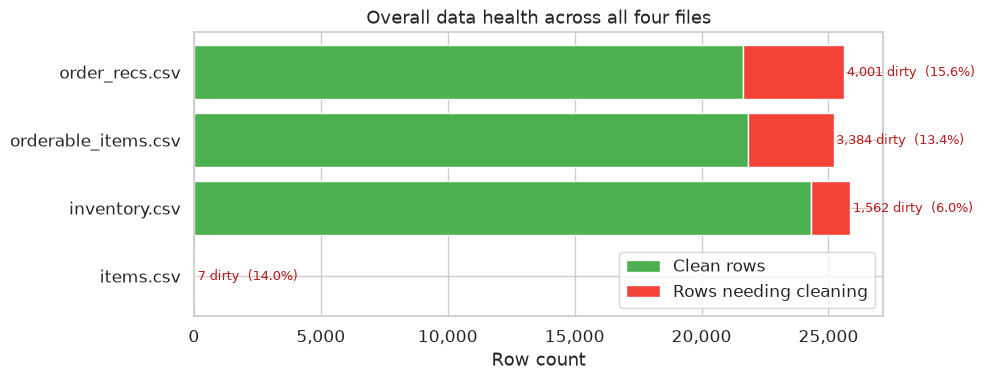

Total rows across all files : 76,745
Rows needing cleaning       : 8,954  (11.7%)
Clean rows                  : 67,791  (88.3%)


In [29]:
# Final combined health bar -------
file_labels = ["items.csv", "inventory.csv", "orderable_items.csv", "order_recs.csv"]
clean_counts = [
    items_clean,
    n_clean,
    n_ord_clean,
    n_rec_clean,
]
dirty_counts = [
    items_dirty,
    n_dirty,
    n_ord_dirty,
    n_rec_dirty,
]
totals = [len(items), len(inventory), len(orderable), len(recs)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(file_labels, clean_counts, color=HEALTHY_COLOR, label="Clean rows")
ax.barh(file_labels, dirty_counts, left=clean_counts,   color=DIRTY_COLOR,   label="Rows needing cleaning")
for i, (c, d, t) in enumerate(zip(clean_counts, dirty_counts, totals)):
    ax.text(t + 100, i, f"{d:,} dirty  ({d/t*100:.1f}%)", va="center", fontsize=9, color="#B71C1C")
ax.set_xlabel("Row count")
ax.set_title("Overall data health across all four files")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

all_total = sum(totals)
all_dirty = sum(dirty_counts)
print(f"Total rows across all files : {all_total:,}")
print(f"Rows needing cleaning       : {all_dirty:,}  ({all_dirty/all_total*100:.1f}%)")
print(f"Clean rows                  : {all_total - all_dirty:,}  ({(all_total-all_dirty)/all_total*100:.1f}%)")